In [1]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import MACCSkeys

In [2]:
import random
import numpy as np
import pandas as pd
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, RocCurveDisplay, auc, roc_auc_score, matthews_corrcoef

In [4]:
import matplotlib.pyplot as plt

In [5]:
df1 = pd.read_csv('./ido1_tdo_fulljoin_20260205.csv', na_values=['na'])
#df1 = df1.dropna(ignore_index=True)
df1

,molecule_chembl_id,smiles,ido1_ic50,tdo_ic50
0,CHEMBL412131,Cc1c(SC[C@H](NC(=O)CC[C@H](N)C(=O)O)C(=O)NCC(=...,340.0,NaN
1,CHEMBL565489,Cc1cccc(N/C(=N\O)c2nonc2N)c1,550.0,NaN
2,CHEMBL107103,O=C(c1ccccc1)c1cccc(O)c1,500000.0,NaN
3,CHEMBL3342385,CCOC(=O)c1cnc2scc(C3=CCCCC3)n12,100000.0,NaN
4,CHEMBL3765545,O=C1CCc2cc(S(=O)(=O)NNc3ccc(Br)cc3)ccc2N1,72.7,NaN
...,...,...,...,...
4586,CHEMBL6053460,N#Cc1cc(-c2c[nH]c3cc(F)ccc23)ccc1S(=O)(=O)N1CC...,NaN,730.0
4587,CHEMBL5819188,NC(=O)CNc1ccc(-c2c[nH]c3cc(F)ccc23)cn1,NaN,790.0
4588,CHEMBL4849018,OCC(O)Cn1nnc2ccc(-c3c[nH]c4ccccc34)cc21,NaN,25200.0
4589,CHEMBL4176841,Cc1ccn(-c2cnoc2N)n1,NaN,1600.0


In [6]:
df2 = df1.loc[:, ['ido1_ic50', 'tdo_ic50']]
df2

,ido1_ic50,tdo_ic50
0,340.0,NaN
1,550.0,NaN
2,500000.0,NaN
3,100000.0,NaN
4,72.7,NaN
...,...,...
4586,NaN,730.0
4587,NaN,790.0
4588,NaN,25200.0
4589,NaN,1600.0


In [7]:
for i in range(len(df2)):
    if df2['ido1_ic50'].values[i] <= 1000:
        df2.loc[i, ['ido1_ic50']] = 1
    elif df2['ido1_ic50'].values[i] > 1000:
        df2.loc[i, ['ido1_ic50']] = 0
    else:
        df2.loc[i, ['ido1_ic50']] = np.nan

In [8]:
for i in range(len(df2)):
    if df2['tdo_ic50'].values[i] <= 1000:
        df2.loc[i, ['tdo_ic50']] = 1
    elif df2['tdo_ic50'].values[i] > 1000:
        df2.loc[i, ['tdo_ic50']] = 0
    else:
        df2.loc[i, ['tdo_ic50']] = np.nan

In [9]:
df2

,ido1_ic50,tdo_ic50
0,1.0,NaN
1,1.0,NaN
2,0.0,NaN
3,0.0,NaN
4,1.0,NaN
...,...,...
4586,NaN,1.0
4587,NaN,1.0
4588,NaN,0.0
4589,NaN,0.0


In [10]:
newcol = []
for i in range(len(df2)):
    if df2['ido1_ic50'].values[i] == 1.0 and df2['tdo_ic50'].values[i] == 1.0:
        newcol.append('AA')
    elif df2['ido1_ic50'].values[i] == 0.0 and df2['tdo_ic50'].values[i] == 0.0:
        newcol.append('II')
    elif df2['ido1_ic50'].values[i] == 0.0 and df2['tdo_ic50'].values[i] == 1.0:
        newcol.append('IA')
    elif df2['ido1_ic50'].values[i] == 1.0 and df2['tdo_ic50'].values[i] == 0.0:
        newcol.append('AI')
    else:
        newcol.append(np.nan)

In [11]:
len(newcol)

4591

In [12]:
target = pd.DataFrame(data=newcol, columns=['ido_tdo'])
target

,ido_tdo
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4586,NaN
4587,NaN
4588,NaN
4589,NaN


In [13]:
y = target.values.reshape(len(df2),)
y.shape

(4591,)

In [14]:
#Identify labeled nodes
# Boolean mask for labeled nodes
labeled_mask = target['ido_tdo'].notna()

# Get indices of labeled nodes
labeled_indices = target.index[labeled_mask].to_numpy()  # 1126 nodes


In [15]:
labeled_indices.shape

(1126,)

In [16]:
labeled_indices

array([3294, 3295, 3296, ..., 4417, 4418, 4419])

In [17]:
y[labeled_indices]

array(['AA', 'AI', 'II', ..., 'II', 'AA', 'AI'], dtype=object)

In [18]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_label = encoder.fit_transform(y[labeled_indices])

In [19]:
y_label

array([0, 1, 3, ..., 3, 0, 1])

In [20]:
# Random & Stratify split
from sklearn.model_selection import train_test_split

def stratified_split_indices(labeled_indices, y_label, train_ratio=0.6, val_ratio=0.2, seed=42):
    """
    Stratified split of labeled_indices into train/val/test, stratified by y_label.
    Returns train_idx, val_idx, test_idx (subsets of labeled_indices).
    """
    labeled_indices = np.asarray(labeled_indices)
    y_label = np.asarray(y_label)

    test_ratio = 1.0 - train_ratio - val_ratio

    # First split: train vs (val+test)
    train_idx, temp_idx, train_y, temp_y = train_test_split(
        labeled_indices,
        y_label,
        train_size=train_ratio,
        stratify=y_label,
        random_state=seed
    )

    # Second split: val vs test (relative proportions within temp)
    val_size_relative = val_ratio / (val_ratio + test_ratio)
    val_idx, test_idx, val_y, test_y = train_test_split(
        temp_idx,
        temp_y,
        train_size=val_size_relative,
        stratify=temp_y,
        random_state=seed
    )

    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = stratified_split_indices(
    labeled_indices,
    y_label,
    train_ratio=0.6,
    val_ratio=0.2,
    seed=42
)

print("Train size:", len(train_idx))
print("Val size:", len(val_idx))
print("Test size:", len(test_idx))

Train size: 675
Val size: 225
Test size: 226


In [21]:
test_idx

array([3457, 4103, 4032, 3977, 4338, 4397, 3384, 3980, 3701, 3316, 4092,
       4376, 3371, 4391, 4142, 3839, 4043, 4320, 3519, 3708, 3309, 4089,
       4333, 4304, 3975, 3778, 3827, 3840, 4352, 3541, 3386, 3781, 3566,
       4183, 3817, 3436, 4019, 4189, 4126, 4359, 4314, 4281, 4131, 4389,
       3875, 3864, 3713, 3556, 3377, 3843, 3725, 3815, 3339, 4402, 3887,
       4245, 3325, 3343, 3605, 3806, 3883, 3299, 4400, 3712, 4169, 3986,
       3594, 3439, 3836, 3695, 3640, 3393, 4097, 3928, 3334, 4080, 3925,
       4177, 4102, 4416, 3767, 4306, 3608, 3312, 4337, 4387, 3766, 3729,
       3336, 4152, 3646, 4283, 3903, 4063, 3523, 4231, 4275, 3978, 4111,
       3991, 3349, 3771, 3546, 3406, 3997, 4095, 3841, 4011, 3460, 3944,
       4280, 3650, 4414, 3586, 3629, 4106, 3426, 3633, 3671, 4296, 3392,
       3507, 4322, 3770, 3964, 4137, 3893, 3524, 4184, 3411, 4383, 4143,
       3535, 3619, 3331, 4157, 4091, 3896, 3310, 4161, 4317, 3804, 4410,
       3500, 3545, 3321, 3832, 4265, 4236, 3953, 41

In [23]:
#With stratified split:
len(train_idx), len(val_idx), len(test_idx)

(675, 225, 226)

In [24]:
#Create PyG masks
num_nodes = len(target)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True


In [25]:
train_mask.size(), test_mask.size()

(torch.Size([4591]), torch.Size([4591]))

In [26]:
train_idx.shape

(675,)

In [27]:
from rdkit.Chem import SaltRemover as sr
remover = sr.SaltRemover()

In [28]:
mols = []
for i in range(len(df1)):
    try:
        mol_i = Chem.MolFromSmiles(df1['smiles'][i])
        if mol_i is None:
            print(f"[WARNING] Invalid SMILES at index {i}, skipping.")
            mols.append(None)  # Maintain indexing for multiprocessing
            continue
        mol_i = remover.StripMol(mol_i, dontRemoveEverything=True)
        mols.append(mol_i)
    except Exception as e:
        print(e)
len(mols)

4591

In [29]:
smiles_list = [df1['smiles'][i] for i in range(len(df1['smiles']))]

In [30]:
names_list = [df1['molecule_chembl_id'][i] for i in range(len(df1['molecule_chembl_id']))]

In [ ]:
#Deprecated method for Morgan as ExplicitBitVect
FPs = [AllChem.GetMorganFingerprintAsBitVect(mols[i], radius=3, nBits=1024) for i in range(len(mols))]

In [32]:
similarity_matrix = np.zeros((len(FPs), len(FPs)))

In [33]:
similarity_matrix.shape

(4591, 4591)

In [34]:
#Calculate the diagonal elements
for i in range(len(FPs)):
    for j in range(i, len(FPs)):  # Avoid duplicate calculations
        similarity = DataStructs.TanimotoSimilarity(FPs[i], FPs[j])
        similarity_matrix[i, j] = similarity
        similarity_matrix[j, i] = similarity

In [35]:
similarity_matrix.shape

(4591, 4591)

In [36]:
import seaborn as sns

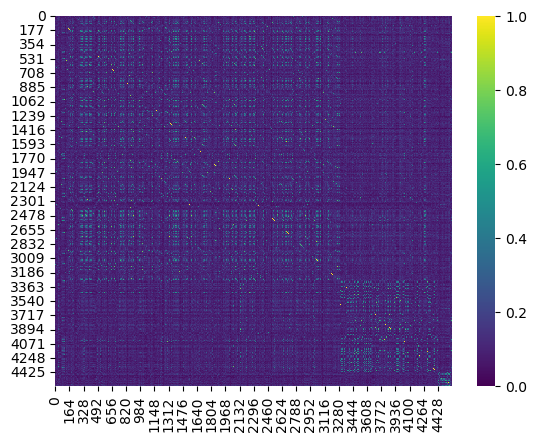

In [37]:
#Tanimoto
sns.heatmap(similarity_matrix, cmap='viridis');

In [38]:
similarity_matrix.min(), similarity_matrix.max(), similarity_matrix.mean()

(0.0, 1.0, 0.11476852948471082)

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7930f17e1460>],
 'cmeans': <matplotlib.collections.LineCollection at 0x7930f17e3800>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x7930f197b5f0>,
 'cmins': <matplotlib.collections.LineCollection at 0x7930f17edeb0>,
 'cbars': <matplotlib.collections.LineCollection at 0x7930f17ec4a0>,
 'cmedians': <matplotlib.collections.LineCollection at 0x7930f1866b70>}

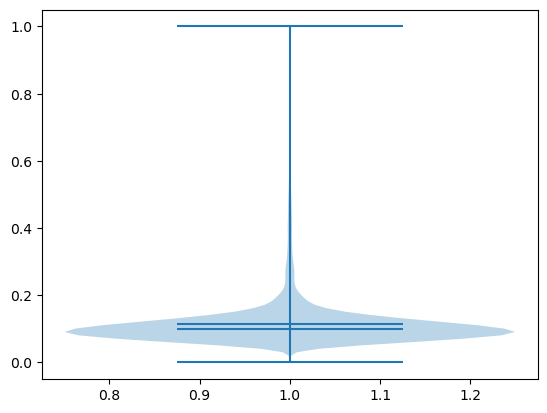

In [39]:
#Tanimoto
plt.violinplot(similarity_matrix.flatten(), showmeans=True, showmedians=True)

In [40]:
import networkx as nx

In [41]:
#Build k-NN graph from similarity matrix
k = 15  # start with 10–20

In [42]:
#Mutual k-NN
#This avoids hubs:
max_w = np.max(similarity_matrix ** 2)
edges = set()
num_nodes = similarity_matrix.shape[0]
for i in range(num_nodes):
    sims = similarity_matrix[i]
    nn_idx = np.argsort(sims)[::-1][1:k+1]
    for j in nn_idx:
        edges.add((i, j))

G = nx.Graph()
for i, j in edges:
    if (j, i) in edges:
        w = (similarity_matrix[i, j]**2) / max_w
        G.add_edge(i, j, weight=w)

In [43]:
len(G.nodes), len(G.edges)

(4510, 22254)

In [44]:
G.number_of_nodes(), G.number_of_edges()

(4510, 22254)

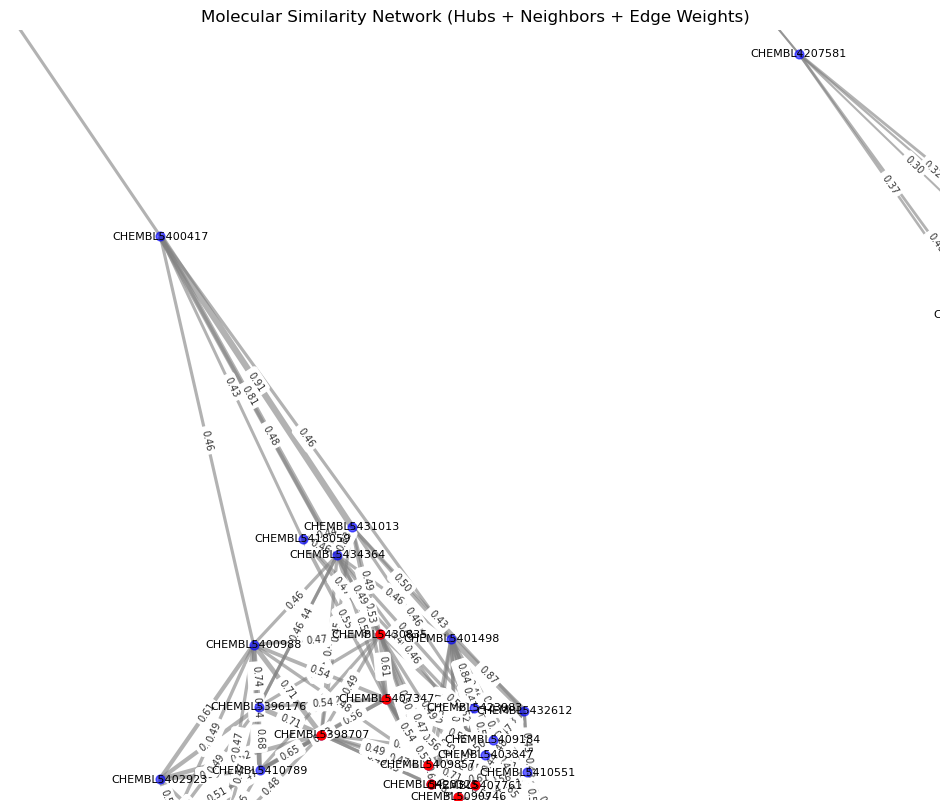

In [45]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 10))

# Work on a copy
G_clean = G.copy()
G_clean.remove_edges_from(nx.selfloop_edges(G_clean))

# Degree dictionary
degree_dict = dict(G_clean.degree())

# Select high-degree nodes
high_degree_nodes = [n for n, d in degree_dict.items() if d > 14]

# Neighbors of high-degree nodes
neighbor_nodes = set()
for node in high_degree_nodes:
    neighbor_nodes.update(G_clean.neighbors(node))

# Nodes to draw
nodes_to_draw = set(high_degree_nodes) | neighbor_nodes

# Subgraph
H = G_clean.subgraph(nodes_to_draw)

# Layout
pos = nx.spring_layout(H, seed=42)

# --- Draw edges with width proportional to weight ---
edges = H.edges(data=True)
edge_weights = [d['weight']*5 for u, v, d in edges]  # scale for visibility
nx.draw_networkx_edges(
    H,
    pos,
    width=edge_weights,
    edge_color="gray",
    alpha=0.6
)

# --- Draw nodes ---
nx.draw_networkx_nodes(
    H,
    pos,
    nodelist=list(neighbor_nodes),
    node_size=40,
    node_color="blue",
    alpha=0.6
)

nx.draw_networkx_nodes(
    H,
    pos,
    nodelist=high_degree_nodes,
    node_size=40,
    node_color="red"
)

# --- Node labels ---
label_dict = {i: names_list[i] for i in H.nodes()}
nx.draw_networkx_labels(H, pos, labels=label_dict, font_size=8)

# --- Edge weight labels ---
# Create dictionary: key=(u,v), value=weight (rounded)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in H.edges(data=True)}

nx.draw_networkx_edge_labels(
    H,
    pos,
    edge_labels=edge_labels,
    font_size=7,
    label_pos=0.5,   # position along edge (0=start, 0.5=center)
    rotate=True,
    alpha=0.8
)

plt.title("Molecular Similarity Network (Hubs + Neighbors + Edge Weights)")
plt.axis("off")
plt.xlim(-0.2, -0.1)
plt.ylim(-0.2, -0.1)
#plt.show()
# Or save
plt.savefig("network_with_edge_weights.png", dpi=300, bbox_inches="tight")

In [46]:
G.is_directed()

False

In [47]:
G.number_of_edges(), G.number_of_nodes()

(22254, 4510)

In [48]:
#Step 1: Compute Morgan fingerprints

In [49]:
# Suppose you have a list of SMILES strings for your dataset
def morgan_fp(smiles, radius=2, nBits=1024):
    mol = Chem.MolFromSmiles(smiles)
    fpgen = AllChem.GetMorganGenerator(fpSize=1024)
    arr_fp = fpgen.GetFingerprintAsNumPy(mol)
    return arr_fp

node_features = np.array([morgan_fp(s) for s in smiles_list])  # shape (4591, 1024)

In [50]:
node_features.shape

(4591, 1024)

In [51]:
#For PyG, node labels should be integers (0–3 for 4 classes).
# Map class names to integers
class_mapping = {'AA': 0, 'AI': 1, 'IA': 2, 'II': 3}
labels = target['ido_tdo'].map(class_mapping)

# Replace NaN with -1 (unlabeled)
labels = labels.fillna(-1).astype(int)

y = torch.tensor(labels.values, dtype=torch.long)

In [52]:
y

tensor([-1, -1, -1,  ..., -1, -1, -1])

In [53]:
#In the following steps, we are preparing and converting the data to a pytorch compatible input data.

In [54]:
#Step 2: Build edge list with weights from NetworkX

In [55]:
import torch
from torch_geometric.data import Data

# Assume G is your weighted NetworkX graph
edge_index = []
edge_attr = []

for u, v, data in G.edges(data=True):
    edge_index.append([u, v])
    edge_index.append([v, u])  # undirected graph → add both directions
    edge_attr.append([data['weight']])
    edge_attr.append([data['weight']])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()  # shape [2, num_edges]
edge_attr = torch.tensor(edge_attr, dtype=torch.float)                   # shape [num_edges, 1]

In [56]:
#Step 3: Add node features and labels

In [57]:
# Convert node features to tensor
x = torch.tensor(node_features, dtype=torch.float)  # shape [4591, 1024]

In [58]:
#Step 4: Create PyTorch Geometric Data object

In [59]:
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

print(data)
# Data(x=[760, 2048], edge_index=[2, num_edges], edge_attr=[num_edges, 1], y=[760])

Data(x=[4591, 1024], edge_index=[2, 44508], edge_attr=[44508, 1], y=[4591])


In [60]:
data.edge_attr.shape

torch.Size([44508, 1])

In [61]:
# Attach to data object
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

In [62]:
data.train_mask.sum()

tensor(675)

In [63]:
# Assuming your Data object is already built with x, edge_index, edge_attr, y

print("Train nodes:", data.train_mask.sum().item())
print("Val nodes:", data.val_mask.sum().item())
print("Test nodes:", data.test_mask.sum().item())

Train nodes: 675
Val nodes: 225
Test nodes: 226


In [64]:
data.has_self_loops(), data.has_isolated_nodes()

(True, True)

In [65]:
#Node classification task

In [66]:
data.num_classes = 4

In [67]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [68]:
#GCN model
import torch
import torch.nn.functional as F
from torch.nn import Linear, Dropout
from torch_geometric.nn import GCNConv, LayerNorm


class GCN(torch.nn.Module):
    def __init__(self, num_features, num_classes, dropout=0.5):
        super().__init__()

        # ----- GCN layers -----
        self.conv1 = GCNConv(num_features, 64)
        self.ln1 = LayerNorm(64)

        self.conv2 = GCNConv(64, 32)
        self.ln2 = LayerNorm(32)

        self.conv3 = GCNConv(32, 16)

        # ----- Skip connections -----
        self.skip1 = Linear(num_features, 64) if num_features != 64 else None
        self.skip2 = Linear(64, 32)
        self.skip3 = Linear(32, 16)

        # ----- Classifier -----
        self.classifier = Linear(16, num_classes)
        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_weight=None):
        # ===== Layer 1 =====
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index, edge_weight=edge_weight)
        h = h + residual
        h = F.relu(h)
        h = self.ln1(h)
        h = self.dropout(h)

        # ===== Layer 2 =====
        residual = self.skip2(h)
        h = self.conv2(h, edge_index, edge_weight=edge_weight)
        h = h + residual
        h = F.relu(h)
        h = self.ln2(h)
        h = self.dropout(h)

        # ===== Layer 3 =====
        residual = self.skip3(h)
        h = self.conv3(h, edge_index, edge_weight=edge_weight)
        h = h + residual
        h = F.relu(h)

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [69]:
# Transductive GCN

data = data.to(device)
model = GCN(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()  # Changed for log_softmax output
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, edge_weight=data.edge_attr.squeeze())
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
    optimizer.step()

    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, edge_weight=data.edge_attr.squeeze())  # Consistent edge_weight
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(200):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    # Early stopping and checkpointing
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_gcn_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")
        

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model for final test - SECURE
checkpoint = torch.load('best_gcn_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


Train/Val/Test nodes: 675/225/226
Epoch 000 | Train Loss: 1.5249 | Train Acc: 0.2178 | Val Loss: 1.2068 | Val Acc: 0.5022 | Best: 0.5022
Epoch 010 | Train Loss: 0.8239 | Train Acc: 0.6830 | Val Loss: 0.7738 | Val Acc: 0.7067 | Best: 0.7067
Epoch 020 | Train Loss: 0.6419 | Train Acc: 0.7793 | Val Loss: 0.6547 | Val Acc: 0.7378 | Best: 0.7378
Epoch 030 | Train Loss: 0.5294 | Train Acc: 0.8089 | Val Loss: 0.6631 | Val Acc: 0.7422 | Best: 0.7556
Epoch 040 | Train Loss: 0.4300 | Train Acc: 0.8296 | Val Loss: 0.6948 | Val Acc: 0.7467 | Best: 0.7644
Epoch 050 | Train Loss: 0.3869 | Train Acc: 0.8444 | Val Loss: 0.7774 | Val Acc: 0.7422 | Best: 0.7644
Epoch 060 | Train Loss: 0.3441 | Train Acc: 0.8533 | Val Loss: 0.8230 | Val Acc: 0.7333 | Best: 0.7644
Epoch 070 | Train Loss: 0.3045 | Train Acc: 0.8874 | Val Loss: 0.9508 | Val Acc: 0.7244 | Best: 0.7644
Epoch 080 | Train Loss: 0.2807 | Train Acc: 0.8904 | Val Loss: 0.9658 | Val Acc: 0.7111 | Best: 0.7644
Early stopping at epoch 85
Test Loss: 0

In [70]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.716     0.849     0.777        86
           1      0.754     0.676     0.713        68
           2      0.600     0.300     0.400        10
           3      0.793     0.742     0.767        62

    accuracy                          0.743       226
   macro avg      0.716     0.642     0.664       226
weighted avg      0.743     0.743     0.738       226



In [71]:
out_test.shape

torch.Size([4591, 4])

In [72]:
import torch.nn.functional as F

In [73]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [74]:
y_true.shape

torch.Size([226])

In [75]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.9102706038644997

In [76]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average=None)

array([0.90398671, 0.9153481 , 0.90185185, 0.91989575])

In [77]:
matthews_corrcoef(y_true, y_pred)

0.6234514786143649

In [78]:
#GINConv model
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, BatchNorm

class GIN(nn.Module):
    def __init__(self, num_features, num_classes, hidden_dims=(64, 32, 16), dropout=0.4):
        super().__init__()

        def mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Linear(out_dim, out_dim),
            )

        # -------- GIN layers --------
        self.conv1 = GINConv(mlp(num_features, hidden_dims[0]), train_eps=True)
        self.bn1 = BatchNorm(hidden_dims[0])

        self.conv2 = GINConv(mlp(hidden_dims[0], hidden_dims[1]), train_eps=True)
        self.bn2 = BatchNorm(hidden_dims[1])

        self.conv3 = GINConv(mlp(hidden_dims[1], hidden_dims[2]), train_eps=True)

        # -------- Skip connections --------
        self.skip1 = nn.Linear(num_features, hidden_dims[0]) if num_features != hidden_dims[0] else None
        self.skip2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.skip3 = nn.Linear(hidden_dims[1], hidden_dims[2])

        self.classifier = nn.Linear(hidden_dims[2], num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        # ---- Layer 1 ----
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index)
        h = self.dropout(h)
        h = h + residual
        h = self.bn1(h)
        h = F.relu(h)

        # ---- Layer 2 ----
        residual = self.skip2(h)
        h = self.conv2(h, edge_index)
        h = self.dropout(h)
        h = h + residual
        h = self.bn2(h)
        h = F.relu(h)

        # ---- Layer 3 ----
        residual = self.skip3(h)
        h = self.conv3(h, edge_index)
        h = h + residual

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [79]:
#Transductive GIN

data = data.to(device)
model = GIN(num_features=data.num_features, num_classes=data.num_classes).to(device)
criterion = torch.nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

def evaluate(data, mask):
    model.eval()
    with torch.no_grad():
        out, h = model(data.x, data.edge_index)  # full-graph forward
        loss = criterion(out[mask], data.y[mask])
        pred = out[mask].argmax(dim=1)
        acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

num_epochs = 200
for epoch in range(1, num_epochs + 1):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | "
              f"Train Acc: {acc_train:.4f} | Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f}")

# Final test evaluation
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")

Epoch 010 | Train Loss: 0.8555 | Train Acc: 0.6889 | Val Loss: 0.9476 | Val Acc: 0.6533
Epoch 020 | Train Loss: 0.6987 | Train Acc: 0.7541 | Val Loss: 0.8887 | Val Acc: 0.6889
Epoch 030 | Train Loss: 0.6455 | Train Acc: 0.7689 | Val Loss: 0.8453 | Val Acc: 0.6844
Epoch 040 | Train Loss: 0.5635 | Train Acc: 0.7911 | Val Loss: 0.8358 | Val Acc: 0.7467
Epoch 050 | Train Loss: 0.5238 | Train Acc: 0.8044 | Val Loss: 0.7918 | Val Acc: 0.7422
Epoch 060 | Train Loss: 0.4783 | Train Acc: 0.8163 | Val Loss: 0.8236 | Val Acc: 0.7200
Epoch 070 | Train Loss: 0.4427 | Train Acc: 0.8281 | Val Loss: 0.8327 | Val Acc: 0.7511
Epoch 080 | Train Loss: 0.4006 | Train Acc: 0.8311 | Val Loss: 0.8745 | Val Acc: 0.7378
Epoch 090 | Train Loss: 0.3604 | Train Acc: 0.8533 | Val Loss: 0.9268 | Val Acc: 0.7156
Epoch 100 | Train Loss: 0.3438 | Train Acc: 0.8459 | Val Loss: 0.9993 | Val Acc: 0.7333
Epoch 110 | Train Loss: 0.3028 | Train Acc: 0.8770 | Val Loss: 0.9734 | Val Acc: 0.7289
Epoch 120 | Train Loss: 0.2645 |

In [80]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.703     0.744     0.723        86
           1      0.697     0.676     0.687        68
           2      0.308     0.400     0.348        10
           3      0.714     0.645     0.678        62

    accuracy                          0.681       226
   macro avg      0.606     0.616     0.609       226
weighted avg      0.687     0.681     0.683       226



In [81]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [82]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8865341426353095

In [83]:
matthews_corrcoef(y_true, y_pred)

0.5377673013784097

In [84]:
#GINEConv with skip connection
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, BatchNorm

class GINE(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_dims=(64, 32, 16), dropout=0.4):
        super().__init__()

        def node_mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Linear(out_dim, out_dim),
            )

        # -------- GINE layers --------
        self.conv1 = GINEConv(
            node_mlp(num_features, hidden_dims[0]),
            edge_dim=1,
            train_eps=True
        )
        self.bn1 = BatchNorm(hidden_dims[0])

        self.conv2 = GINEConv(
            node_mlp(hidden_dims[0], hidden_dims[1]),
            edge_dim=1,
            train_eps=True
        )
        self.bn2 = BatchNorm(hidden_dims[1])

        self.conv3 = GINEConv(
            node_mlp(hidden_dims[1], hidden_dims[2]),
            edge_dim=1,
            train_eps=True
        )

        # -------- Skip connections --------
        self.skip1 = nn.Linear(num_features, hidden_dims[0]) if num_features != hidden_dims[0] else None
        self.skip2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.skip3 = nn.Linear(hidden_dims[1], hidden_dims[2])

        self.classifier = nn.Linear(hidden_dims[2], num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr):
        # Ensure correct edge shape
        edge_attr = edge_attr.view(-1, 1)

        # ---- Layer 1 ----
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index, edge_attr)
        h = self.dropout(h)
        h = h + residual
        h = self.bn1(h)
        h = F.relu(h)

        # ---- Layer 2 ----
        residual = self.skip2(h)
        h = self.conv2(h, edge_index, edge_attr)
        h = self.dropout(h)
        h = h + residual
        h = self.bn2(h)
        h = F.relu(h)

        # ---- Layer 3 (no activation) ----
        residual = self.skip3(h)
        h = self.conv3(h, edge_index, edge_attr)
        h = h + residual

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [85]:
# Transductive GINE

#device = data.x.device
data = data.to(device)
model = GINE(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()  # Changed for log_softmax
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # Added L2

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Re-enabled gradient clipping
    optimizer.step()
    
    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Enhanced training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("GINE | Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(1, 201):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    # Early stopping + checkpointing
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_gine_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model securely and test
checkpoint = torch.load('best_gine_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"GINE Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


GINE | Train/Val/Test nodes: 675/225/226
Epoch 010 | Train Loss: 0.9778 | Train Acc: 0.5526 | Val Loss: 1.7262 | Val Acc: 0.4400 | Best: 0.5244
Epoch 020 | Train Loss: 0.8442 | Train Acc: 0.6489 | Val Loss: 1.0338 | Val Acc: 0.5600 | Best: 0.6000
Epoch 030 | Train Loss: 0.7242 | Train Acc: 0.6904 | Val Loss: 1.7470 | Val Acc: 0.5644 | Best: 0.6311
Epoch 040 | Train Loss: 0.6282 | Train Acc: 0.7259 | Val Loss: 2.2332 | Val Acc: 0.5511 | Best: 0.6311
Epoch 050 | Train Loss: 0.5558 | Train Acc: 0.7556 | Val Loss: 1.2837 | Val Acc: 0.7244 | Best: 0.7244
Epoch 060 | Train Loss: 0.5105 | Train Acc: 0.7881 | Val Loss: 1.6252 | Val Acc: 0.7378 | Best: 0.7422
Epoch 070 | Train Loss: 0.4302 | Train Acc: 0.8252 | Val Loss: 1.4237 | Val Acc: 0.7422 | Best: 0.7467
Epoch 080 | Train Loss: 0.3662 | Train Acc: 0.8415 | Val Loss: 1.5668 | Val Acc: 0.7244 | Best: 0.7467
Epoch 090 | Train Loss: 0.3054 | Train Acc: 0.8652 | Val Loss: 1.8000 | Val Acc: 0.7156 | Best: 0.7467
Epoch 100 | Train Loss: 0.2619 |

In [86]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.739     0.756     0.747        86
           1      0.719     0.676     0.697        68
           2      0.500     0.100     0.167        10
           3      0.694     0.806     0.746        62

    accuracy                          0.717       226
   macro avg      0.663     0.585     0.589       226
weighted avg      0.710     0.717     0.706       226



In [87]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [88]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.9028704563973932

In [89]:
matthews_corrcoef(y_true, y_pred)

0.5844532071687867

In [90]:
#GATConv model
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, BatchNorm

class GAT_EdgeWeighted(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_dims=(64, 32, 16), dropout=0.4):
        super().__init__()

        # -------- GAT layers (edge-aware) --------
        self.conv1 = GATConv(
            in_channels=num_features,
            out_channels=hidden_dims[0] // 4,
            heads=4,
            concat=True,
            dropout=dropout,
            add_self_loops=True,
            edge_dim=1,          # <-- edge weights used
        )
        self.bn1 = BatchNorm(hidden_dims[0])

        self.conv2 = GATConv(
            in_channels=hidden_dims[0],
            out_channels=hidden_dims[1] // 2,
            heads=2,
            concat=True,
            dropout=dropout,
            add_self_loops=True,
            edge_dim=1,
        )
        self.bn2 = BatchNorm(hidden_dims[1])

        self.conv3 = GATConv(
            in_channels=hidden_dims[1],
            out_channels=hidden_dims[2],
            heads=1,
            concat=False,
            dropout=dropout,
            add_self_loops=True,
            edge_dim=1,
        )

        # -------- Skip connections --------
        self.skip1 = nn.Linear(num_features, hidden_dims[0]) if num_features != hidden_dims[0] else None
        self.skip2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.skip3 = nn.Linear(hidden_dims[1], hidden_dims[2])

        self.classifier = nn.Linear(hidden_dims[2], num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_weight):
        # Ensure edge_weight has shape [E, 1]
        if edge_weight is not None:
            edge_weight = edge_weight.view(-1, 1)

        # ---- Layer 1 ----
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index, edge_weight)
        h = h + residual
        h = self.bn1(h)
        h = F.elu(h)
        h = self.dropout(h)

        # ---- Layer 2 ----
        residual = self.skip2(h)
        h = self.conv2(h, edge_index, edge_weight)
        h = h + residual
        h = self.bn2(h)
        h = F.elu(h)
        h = self.dropout(h)

        # ---- Layer 3 (no activation) ----
        residual = self.skip3(h)
        h = self.conv3(h, edge_index, edge_weight)
        h = h + residual

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [91]:
#Transductive GAT learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
from torch_geometric.nn import GATConv, BatchNorm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data = data.to(device)
model = GAT_EdgeWeighted(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-3)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, data.edge_attr)  # edge_attr passed but ignored
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    
    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, data.edge_attr)  # edge_attr ignored
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("GAT | Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(1, 201):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_gat_transductive_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model securely
checkpoint = torch.load('best_gat_transductive_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"GAT Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


GAT | Train/Val/Test nodes: 675/225/226
Epoch 010 | Train Loss: 0.6020 | Train Acc: 0.7600 | Val Loss: 0.6844 | Val Acc: 0.7111 | Best: 0.7200
Epoch 020 | Train Loss: 0.4447 | Train Acc: 0.8207 | Val Loss: 0.7548 | Val Acc: 0.7244 | Best: 0.7244
Epoch 030 | Train Loss: 0.3685 | Train Acc: 0.8489 | Val Loss: 0.8117 | Val Acc: 0.7333 | Best: 0.7511
Epoch 040 | Train Loss: 0.2777 | Train Acc: 0.8800 | Val Loss: 0.8922 | Val Acc: 0.7556 | Best: 0.7644
Epoch 050 | Train Loss: 0.2303 | Train Acc: 0.9096 | Val Loss: 1.0467 | Val Acc: 0.7289 | Best: 0.7644
Epoch 060 | Train Loss: 0.1300 | Train Acc: 0.9526 | Val Loss: 1.2848 | Val Acc: 0.7244 | Best: 0.7644
Epoch 070 | Train Loss: 0.0899 | Train Acc: 0.9689 | Val Loss: 1.5284 | Val Acc: 0.7200 | Best: 0.7644
Epoch 080 | Train Loss: 0.0776 | Train Acc: 0.9778 | Val Loss: 1.6892 | Val Acc: 0.7111 | Best: 0.7644
Early stopping at epoch 83
GAT Test Loss: 0.8114 | Test Acc: 0.7257


In [92]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.731     0.791     0.760        86
           1      0.723     0.691     0.707        68
           2      0.300     0.300     0.300        10
           3      0.793     0.742     0.767        62

    accuracy                          0.726       226
   macro avg      0.637     0.631     0.633       226
weighted avg      0.727     0.726     0.725       226



In [93]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [94]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8960459952034243

In [95]:
matthews_corrcoef(y_true, y_pred)

0.5998654348672254

In [96]:
import torch
from torch import nn
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import scatter

In [95]:
#SAGEConv layer of PyG does NOT accept edge_weight. So, we have to implement it manually.
#You are using weighted sum aggregation in the below architecture: Sum aggregation Weighted by edge weights.

In [96]:
#PyG’s SAGEConv uses mean by default
#If you want to use weighted-mean GraphSAGE aggregation:

In [97]:
from torch_geometric.utils import scatter

class WeightedMeanSAGEConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, edge_weight=None):
        if edge_weight is None:
            edge_weight = x.new_ones(edge_index.size(1))

        self.edge_weight = edge_weight
        return self.propagate(edge_index, x=x)

    def message(self, x_j):
        return x_j * self.edge_weight.view(-1, 1)

    def aggregate(self, inputs, index):
        weighted_sum = scatter(inputs, index, dim=0, reduce='sum')
        weight_sum = scatter(
            self.edge_weight, index, dim=0, reduce='sum'
        ).view(-1, 1)

        return weighted_sum / (weight_sum + 1e-8)

    def update(self, aggr_out):
        return self.lin(aggr_out)


In [98]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, Dropout
from torch_geometric.nn import BatchNorm

class GraphSAGE(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()

        self.conv1 = WeightedMeanSAGEConv(num_features, 64)
        self.bn1 = BatchNorm(64)

        self.conv2 = WeightedMeanSAGEConv(64, 32)
        self.bn2 = BatchNorm(32)

        self.conv3 = WeightedMeanSAGEConv(32, 16)

        # Skip connections
        self.skip1 = Linear(num_features, 64) if num_features != 64 else None
        self.skip2 = Linear(64, 32)
        self.skip3 = Linear(32, 16)

        self.classifier = Linear(16, num_classes)
        self.dropout = Dropout(p=0.4)

    def forward(self, x, edge_index, edge_weight):
        # ---- Layer 1 ----
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index, edge_weight)
        h = F.relu(h)
        h = self.bn1(h)
        h = h + residual
        h = self.dropout(h)

        # ---- Layer 2 ----
        residual = self.skip2(h)
        h = self.conv2(h, edge_index, edge_weight)
        h = F.relu(h)
        h = self.bn2(h)
        h = h + residual
        h = self.dropout(h)

        # ---- Layer 3 ----
        residual = self.skip3(h)
        h = self.conv3(h, edge_index, edge_weight)
        h = h + residual

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [99]:
# Transductive GraphSAGE

data = data.to(device)
model = GraphSAGE(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()  # Changed for log_softmax
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # Added L2
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Re-enabled gradient clipping
    optimizer.step()
    scheduler.step()
    
    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Enhanced training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("GraphSAGE | Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(1, 201):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    # Early stopping + checkpointing
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_graphSAGE_transductive_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model securely and test
checkpoint = torch.load('best_graphSAGE_transductive_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"GraphSAGE Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


GraphSAGE | Train/Val/Test nodes: 675/225/226
Epoch 010 | Train Loss: 0.4857 | Train Acc: 0.8000 | Val Loss: 0.7858 | Val Acc: 0.6978 | Best: 0.6978
Epoch 020 | Train Loss: 0.2867 | Train Acc: 0.8726 | Val Loss: 0.9703 | Val Acc: 0.7289 | Best: 0.7422
Epoch 030 | Train Loss: 0.1358 | Train Acc: 0.9496 | Val Loss: 1.4741 | Val Acc: 0.7022 | Best: 0.7422
Epoch 040 | Train Loss: 0.0746 | Train Acc: 0.9748 | Val Loss: 1.8663 | Val Acc: 0.7378 | Best: 0.7511
Epoch 050 | Train Loss: 0.0446 | Train Acc: 0.9837 | Val Loss: 2.1738 | Val Acc: 0.7200 | Best: 0.7511
Epoch 060 | Train Loss: 0.0389 | Train Acc: 0.9852 | Val Loss: 2.3294 | Val Acc: 0.7156 | Best: 0.7511
Epoch 070 | Train Loss: 0.0249 | Train Acc: 0.9911 | Val Loss: 2.4904 | Val Acc: 0.7111 | Best: 0.7511
Epoch 080 | Train Loss: 0.0324 | Train Acc: 0.9867 | Val Loss: 2.6212 | Val Acc: 0.6978 | Best: 0.7511
Early stopping at epoch 84
GraphSAGE Test Loss: 1.3759 | Test Acc: 0.7522


In [100]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.714     0.872     0.785        86
           1      0.742     0.721     0.731        68
           2      0.500     0.500     0.500        10
           3      0.911     0.661     0.766        62

    accuracy                          0.752       226
   macro avg      0.717     0.688     0.696       226
weighted avg      0.767     0.752     0.751       226



In [101]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [102]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.9032522496859092

In [103]:
matthews_corrcoef(y_true, y_pred)

0.6411446897519896